In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
from conformal_generation.utils import plot_admissibility_curve, plot_generation_sequence_length

In [2]:
df = pd.read_csv("all_results.csv")

## Admissibility and Sequence Length vs Gamma (Click_prediction_small)

In [3]:
def plot_main_plot(df, dataset, admissible_k_to_plot=30):
    plt.close()
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), constrained_layout=True)

    dh = df[df["dataset"] == dataset]
    dh = dh[dh["admissible_k"] == admissible_k_to_plot]
    dh = dh[dh["fold"] == 0]

    is_lambda_inf = dict(zip(dh["gamma"], np.isnan(dh["exp. adm."])))
    admissibility_results = dict(zip(dh["gamma"], dh["exp. adm."].fillna(1)))
    avg_length_conformal = dict(zip(dh["gamma"], dh["Avg Tree Used"].fillna(100)))

    plot_admissibility_curve(ax1, admissibility_results, is_lambda_inf, is_calibration=False)
    plot_generation_sequence_length(ax2, avg_length_conformal, avg_length_conformal, 100)

    plt.show()

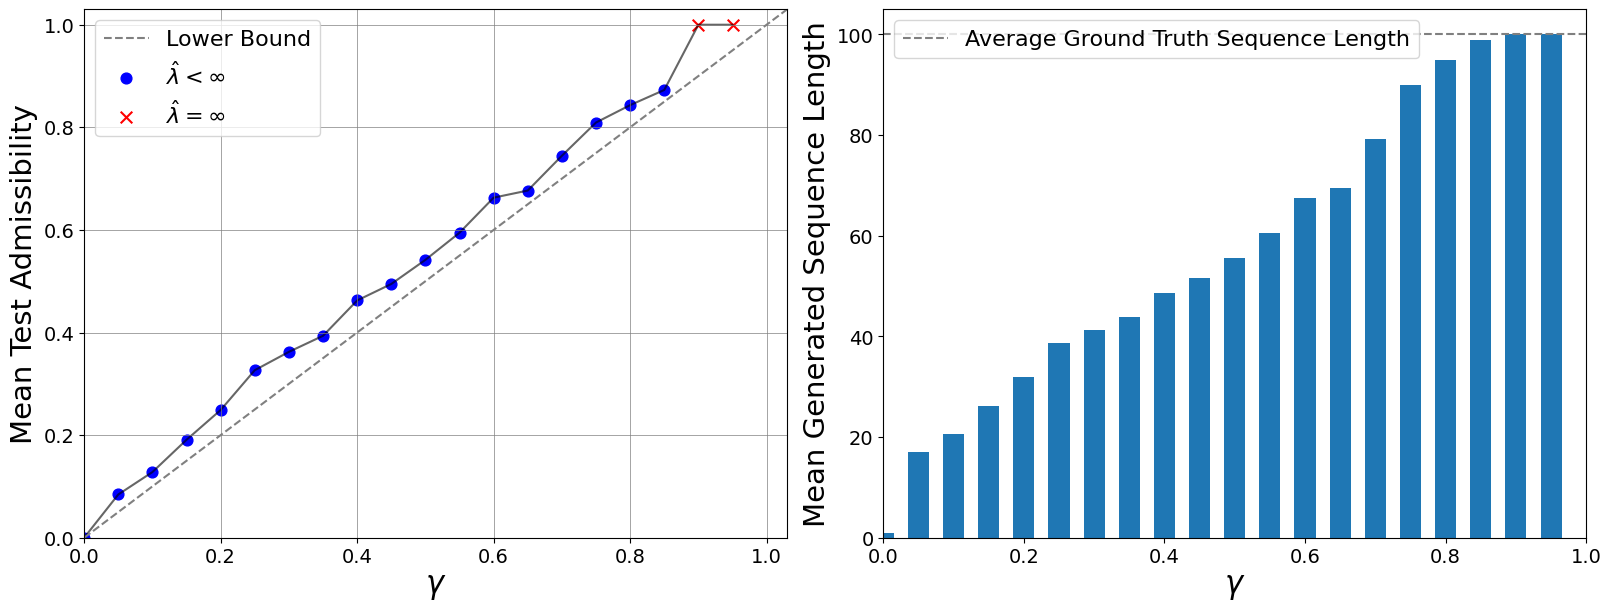

In [4]:
plot_main_plot(df, "Click_prediction_small")

## Other datasets

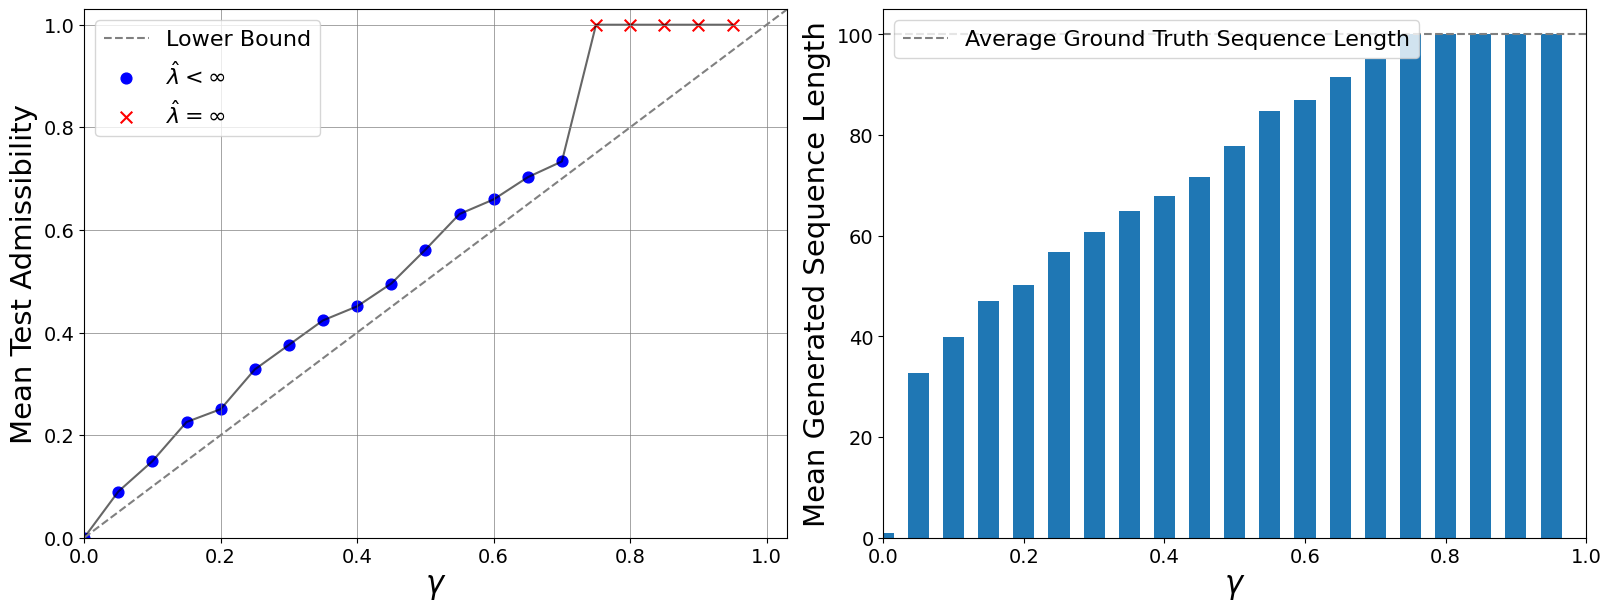

In [5]:
plot_main_plot(df, "GesturePhaseSegmentationProcessed")

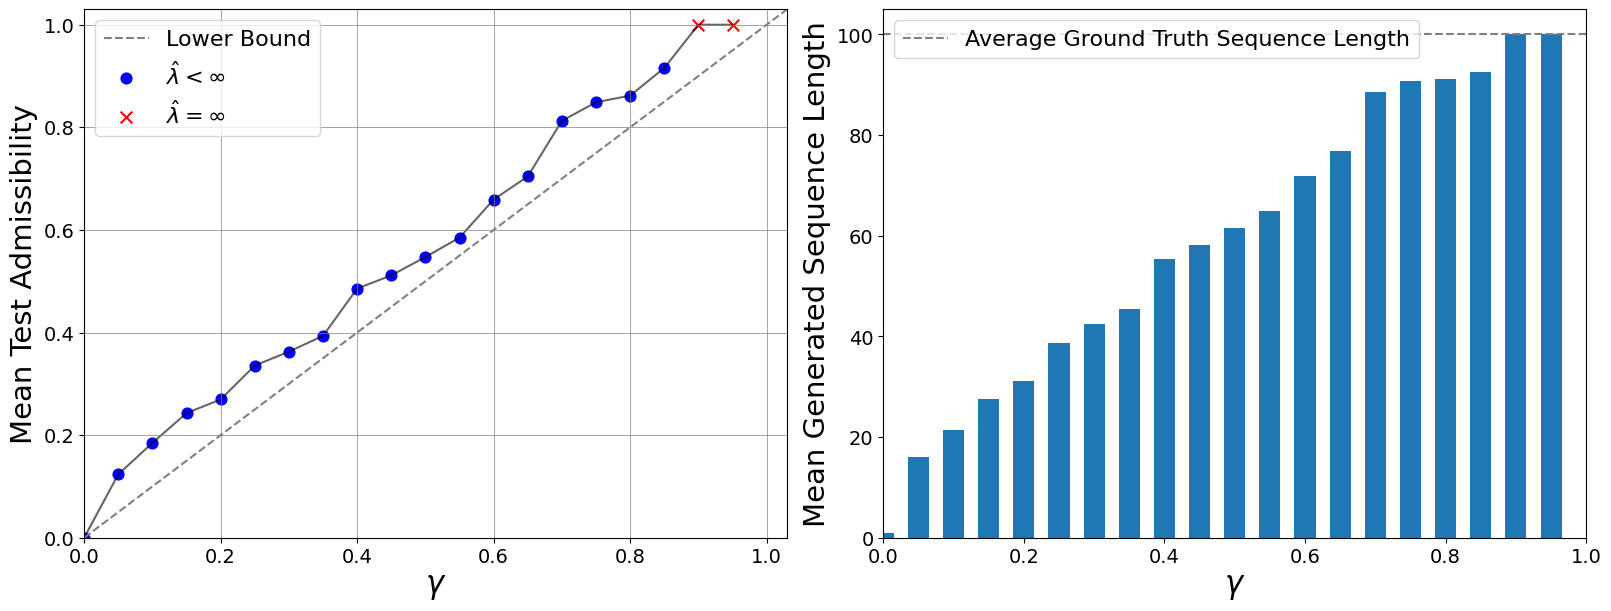

In [6]:
plot_main_plot(df, "adult")

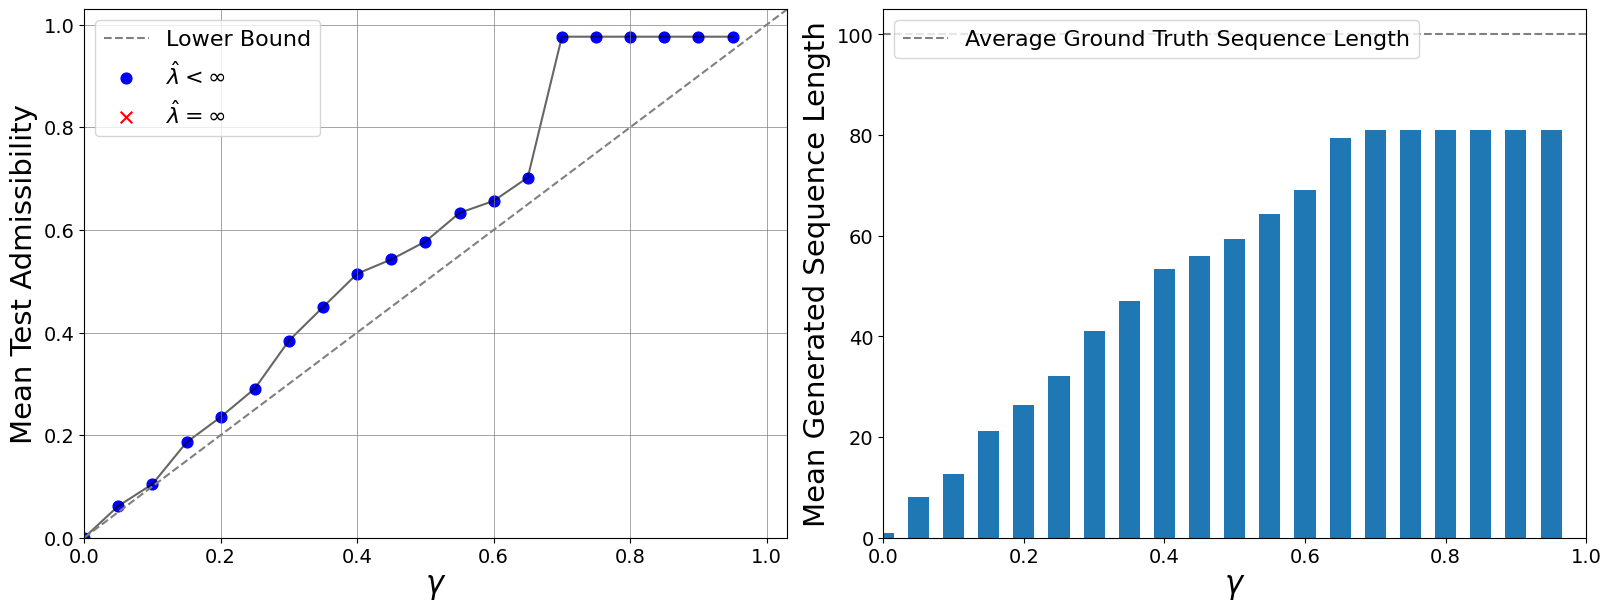

In [7]:
plot_main_plot(df, "Census-Income")

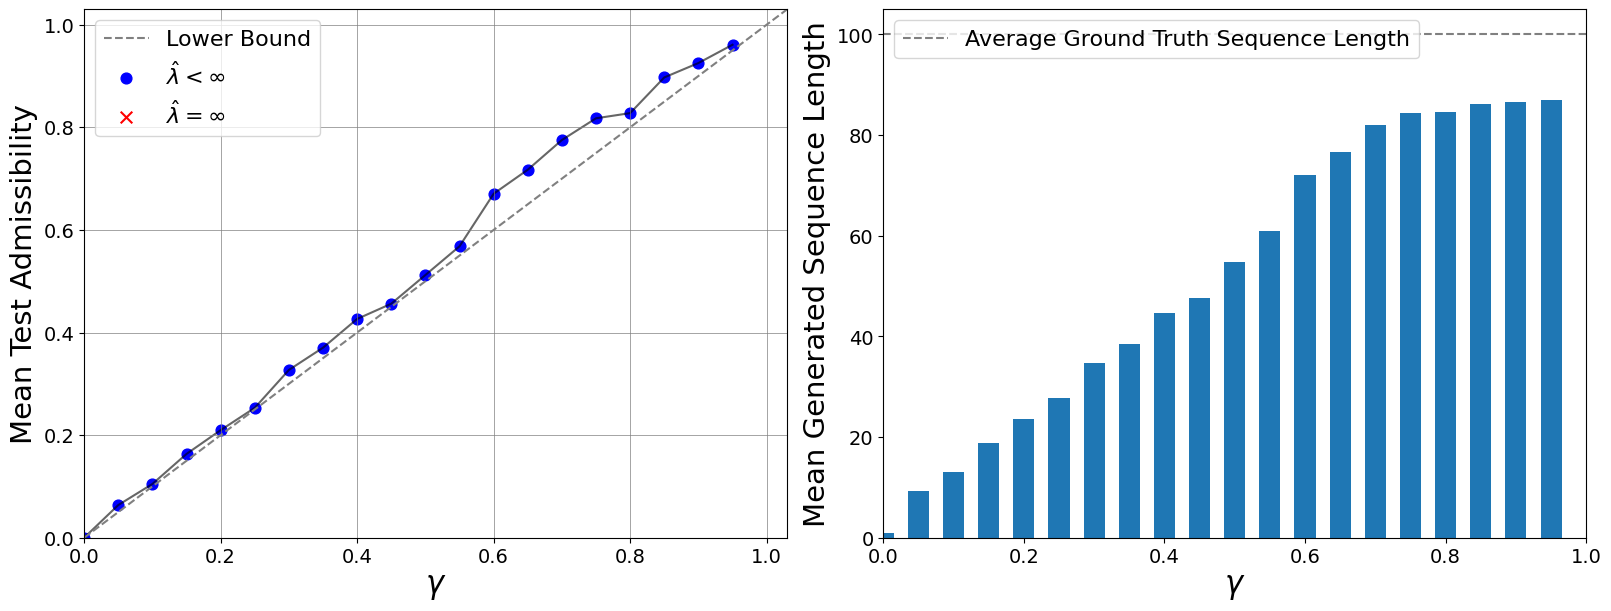

In [8]:
plot_main_plot(df, "MiniBooNE")

## AUC Diff and Averge number of trees used

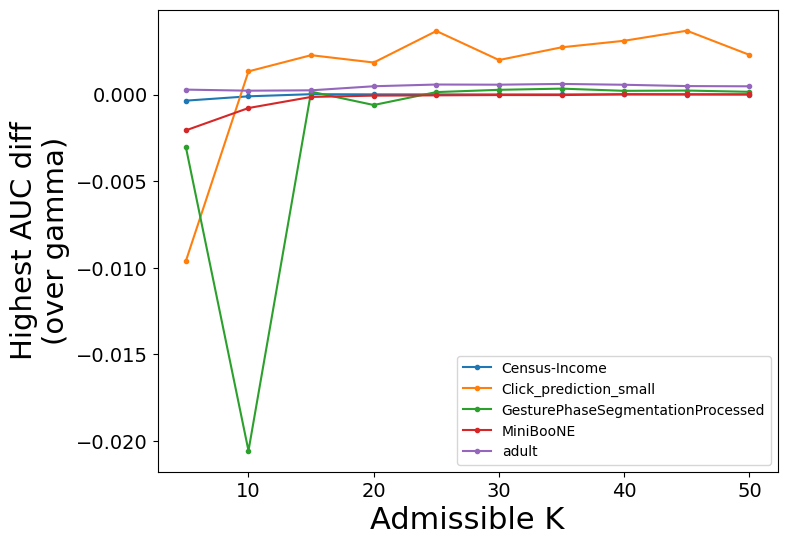

In [9]:
plt.close()
fig, ax = plt.subplots(ncols=1, figsize=(8, 6))
for dataset, dh in df.groupby("dataset"):
    x = []
    y = []
    dh = dh[dh["fold"] == 0]
    dh = dh[dh["admissible_k"] > 1]
    
    for admissible_k, dg in dh.groupby("admissible_k"):
        first = dg.sort_values(by="AUC diff", ascending=False).iloc[0]
        x.append(admissible_k)
        y.append(first.loc["AUC diff"])
    ax.plot(x, y, marker=".", label=dataset)
    ax.set_xlabel("Admissible K", fontsize=22)
    ax.set_ylabel("Highest AUC diff\n(over gamma)", fontsize=21)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

ax.legend()
plt.show()